In [2]:
## init mongo db and fiftyone connection
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [4]:
import fiftyone.brain as fob
from sklearn.preprocessing import normalize
import plotly.express as px
import skdim
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import ot
from sklearn.manifold import TSNE
import cv2
from fiftyone import ViewField as F
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
import random
import glob 
import math
# ## renders plotly properly in a html instance. 
# import plotly.io as pio
# pio.renderers.default = "notebook"


In [5]:
## Load dataset and views from mongodb 
dataset = fo.load_dataset("dugong")

## load the views
nc_view = dataset.match(F('region').starts_with('NC'))
wp_view = dataset.match(F('region').starts_with('WP'))


In [9]:
dataset.save_view("nc", nc_view)
dataset.save_view("wp", wp_view)

In [6]:
dataset.distinct('tags')

['notin_TEST_0',
 'notin_TEST_10',
 'notin_TEST_6',
 'notin_val_0',
 'notin_val_10',
 'notin_val_6',
 'test_0',
 'test_10',
 'test_6',
 'train_0',
 'train_10',
 'train_6',
 'val_0',
 'val_10',
 'val_6']

In [12]:
dataset.untag_samples(['notin_TEST_0',
 'notin_TEST_1',
 'notin_TEST_1000',
 'notin_val_0',
 'notin_val_1',
 'notin_val_1000',
 'test_0',
 'test_1',
 'test_1000',
 'test_1002',
 'test_2000',
 'test_2001',
 'test_2002',
 'train_0',
 'train_1',
 'train_1000',
 'train_1002',
 'train_2000',
 'train_2001',
 'train_2002',
 'train_2004',
 'val_0',
 'val_1',
 'val_1000',
 'val_1002',
 'val_2000',
 'val_2001',
 'val_2002'])

In [7]:
path_wpartitions = '/share/home/e2406743/dataset/df_filepaths'
fff = 'df_train_test_split_filepath_PATCHES_wpartitions_seed_10.parquet'
import pandas as pd
import os

dff = pd.read_parquet(os.path.join(path_wpartitions,fff))
dff.head()

,partition_2,partition_4,partition_12,partition_24,partition_36,partition_44,partition_46,partition_49,ACLR_partition_2,ACLR_partition_4,ACLR_partition_12,ACLR_partition_24,ACLR_partition_36,ACLR_partition_44,ACLR_partition_46,ACLR_partition_49
images,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...
labels,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...
metadata,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...,[/share/home/e2406743/dataset/exported_img/see...


In [12]:
assert 'partition_2' in dff.columns.tolist()

In [9]:

# create a combined key: e.g., "WP_UM_medium" or "WP_GAM_high"
# ensures the split respects both the location and the difficulty
dataset.set_values(
    "stratify_key",
    [f"{r}_{m}_{c}" for r, m, c in zip(
        dataset.values("region"), 
        dataset.values("subregion"), 
        dataset.values("mission_name")
    )]
)

print("Unique strata created:", dataset.count_values("stratify_key"))

Unique strata created: {'WP_UM_UM_M5': 449, 'WP_FRIWEN_FRIWEN_M19': 14, 'NC_NC_Flight_215': 37, 'WP_FRIWEN_FRIWEN_M8': 222, 'NC_NC_Flight_213': 41, 'NC_NC_Flight_218': 22, 'NC_NC_Flight_222': 17, 'NC_NC_Flight_225': 2, 'WP_GAM_GAM_M1': 211, 'WP_UM_UM_M3': 4, 'NC_NC_Flight_200': 10, 'NC_NC_Flight_205': 9, 'NC_NC_Flight_198': 73, 'NC_NC_Flight_232': 23, 'WP_MANTASANDY_MANTASANDY_M5': 3, 'NC_NC_Flight_195': 6, 'WP_FRIWEN_FRIWEN_M53': 4, 'NC_NC_Flight_234': 2, 'WP_UM_UM_M2': 9, 'NC_NC_Flight_235': 4, 'NC_NC_Flight_226': 5, 'NC_NC_Flight_199': 8, 'NC_NC_Flight_211': 17, 'NC_NC_Flight_196': 63, 'NC_NC_Flight_197': 50, 'NC_NC_Flight_220': 20, 'WP_UM_UM_M6': 269, 'NC_NC_Flight_219': 23, 'NC_NC_Flight_214': 19, 'NC_NC_Flight_207': 128, 'NC_NC_Flight_233': 6, 'WP_FRIWEN_FRIWEN_M11': 335, 'NC_NC_Flight_209': 83, 'NC_NC_Flight_212': 36, 'WP_UM_UM_M1': 14, 'NC_NC_Flight_231': 12, 'WP_GAM_GAM_M10': 26, 'WP_FRIWEN_FRIWEN_M12': 204, 'WP_GAM_GAM_M2': 275}


In [155]:
wp_view.count_values('subregion')

{'FRIWEN': 779, 'GAM': 512, 'MANTASANDY': 3, 'UM': 745}

In [94]:
wp_dict_flights = wp_view.match(F("subregion")=="FRIWEN").count_values('stratify_key')
wp_dict_flights

{'WP_FRIWEN_FRIWEN_M12': 204,
 'WP_FRIWEN_FRIWEN_M8': 222,
 'WP_FRIWEN_FRIWEN_M19': 14,
 'WP_FRIWEN_FRIWEN_M11': 335,
 'WP_FRIWEN_FRIWEN_M53': 4}

In [4]:
WP_dict_stratify_key = wp_view.count_values('stratify_key')

In [5]:
wp_view.count_values('subregion')

{'GAM': 512, 'UM': 745, 'FRIWEN': 779, 'MANTASANDY': 3}

In [13]:
dict_stratify = wp_view.count_values('stratify_key')
dict_stratify

{'WP_FRIWEN_FRIWEN_M19': 14,
 'WP_FRIWEN_FRIWEN_M8': 222,
 'WP_FRIWEN_FRIWEN_M12': 204,
 'WP_FRIWEN_FRIWEN_M11': 335,
 'WP_GAM_GAM_M1': 211,
 'WP_GAM_GAM_M2': 275,
 'WP_GAM_GAM_M10': 26,
 'WP_MANTASANDY_MANTASANDY_M5': 3,
 'WP_UM_UM_M5': 449,
 'WP_UM_UM_M3': 4,
 'WP_UM_UM_M2': 9,
 'WP_UM_UM_M6': 269,
 'WP_UM_UM_M1': 14,
 'WP_FRIWEN_FRIWEN_M53': 4}

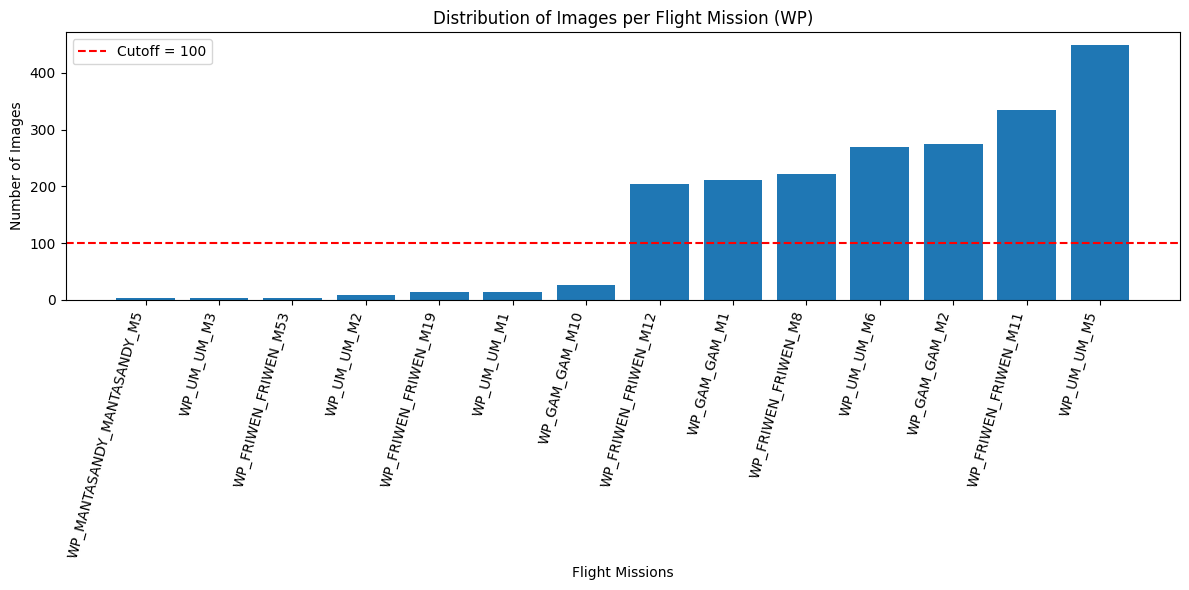

In [10]:
dict_stratify = wp_view.count_values('stratify_key')
# Sort for better visualization (optional but recommended)
sorted_items = sorted(dict_stratify.items(), key=lambda x: x[1])
labels = [k for k, _ in sorted_items]
values = [v for _, v in sorted_items]

# Cutoff line (you can change this)
cutoff = 100

# Plot
plt.figure(figsize=(12, 6))
plt.bar(labels, values)

# Horizontal cutoff line
plt.axhline(y=cutoff, color='red', linestyle='--', label=f'Cutoff = {cutoff}')

# Labels & formatting
plt.xticks(rotation=75, ha='right')
plt.ylabel("Number of Images")
plt.xlabel("Flight Missions")
plt.title("Distribution of Images per Flight Mission (WP)")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
WP_dict_stratify_key

{'WP_FRIWEN_FRIWEN_M8': 222,
 'WP_FRIWEN_FRIWEN_M12': 204,
 'WP_GAM_GAM_M2': 275,
 'WP_UM_UM_M5': 449,
 'WP_GAM_GAM_M1': 211,
 'WP_FRIWEN_FRIWEN_M19': 14,
 'WP_GAM_GAM_M10': 26,
 'WP_MANTASANDY_MANTASANDY_M5': 3,
 'WP_UM_UM_M2': 9,
 'WP_UM_UM_M1': 14,
 'WP_FRIWEN_FRIWEN_M11': 335,
 'WP_UM_UM_M3': 4,
 'WP_UM_UM_M6': 269,
 'WP_FRIWEN_FRIWEN_M53': 4}

In [1]:
dataset.distinct('tags')

NameError: name 'dataset' is not defined

In [33]:
dataset.untag_samples(['notin_TEST_0',
 'notin_TEST_1001',
 'test_0',
 'test_1001',
 'train_0',
 'train_1001',
 'val_0',
 'val_1001'])

In [ ]:
import random
from typing import List, Dict, Optional
from sklearn.model_selection import train_test_split


def find_flight_candidates_WP(
    wp_view,
    wp_train_val_size: float,
    wp_test_size: float,
    subset_size: int,
    seed: int = 0,
    max_tries: int = 100,
    fuzzy: int = 3,
) -> Optional[Dict[str, str]]:
    """
    Find the flights mission candidates to be elected as TEST set only. This will be excluded from the whole
    downstream pipeline.

    Returns:
        dict: {island: selected_flight} if valid
        None: if no valid split found
    """

    rng = random.Random(seed)

    train_val_size = int(subset_size * wp_train_val_size)
    min_test_size = int(subset_size * wp_test_size)

    print(f"Total subset: {subset_size}")
    print(f"Train/Val: {train_val_size}")
    print(f"Test: {min_test_size}")

    # --- Stratify counts ---
    WP_dict_stratify_key = wp_view.count_values("stratify_key")
    proportionality = wp_view.count_values("subregion")

    # --- Remove MANTASANDY from proportionality ---
    full_set = len(wp_view) - proportionality["MANTASANDY"]

    out_prop = {
        k: v / full_set
        for k, v in proportionality.items()
        if k != "MANTASANDY"
    }

    # --- Budgets ---
    proportional_budget_test = {
        k: int(v * min_test_size) for k, v in out_prop.items()
    }

    proportional_budget_trainval = {
        k: int(v * train_val_size) for k, v in out_prop.items()
    }

    print("Test budget:", proportional_budget_test)
    print("Train/Val budget:", proportional_budget_trainval)

    # --- Flights per island ---
    islands_to_split = ["UM", "FRIWEN", "GAM"]

    dict_island = {}
    for island in islands_to_split:
        island_view = wp_view.match(F("subregion") == island)
        dict_island[island] = island_view.distinct("stratify_key")

    flight_keys = set(WP_dict_stratify_key.keys())

    # --- Try multiple times ---
    for attempt in range(max_tries):

        # 1. Sample one flight per island
        flight_candidates = {
            island: rng.choice(flights)
            for island, flights in dict_island.items()
        }

        # 2. Add fixed test flight
        test_flights = set(flight_candidates.values())
        test_flights.add("WP_MANTASANDY_MANTASANDY_M5")  # adjust if needed

        # --- 3. TEST VALIDATION ---
        valid = True

        for island, flight in flight_candidates.items():
            size = WP_dict_stratify_key[flight]
            min_required = proportional_budget_test[island] - fuzzy

            if size < min_required:
                valid = False
                break

        if not valid:
            continue

        # --- 4. TRAIN/VAL VALIDATION ---
        train_val_flights = flight_keys - test_flights

        train_val_by_island = {k: 0 for k in proportional_budget_trainval.keys()}

        for f in train_val_flights:
            island = f.split("_")[1]  # assumes format WP_<ISLAND>_...
            if island in train_val_by_island:
                train_val_by_island[island] += WP_dict_stratify_key[f]

        for island, total in train_val_by_island.items():
            min_required = proportional_budget_trainval[island] - fuzzy

            if total < min_required:
                valid = False
                break

        if valid:
            print(f"[SUCCESS] Found split at attempt {attempt}")
            print("Test flights:", test_flights)
            #for flight in test_flights:
                #print(f"{flight}:{WP_dict_stratify_key[flight]}")
            return flight_candidates,proportional_budget_test

    print("[FAIL] No valid split found")
    return None,None



def tagged_traintest_seeded_split_subset_WP(
    dataset,
    wp_view,
    wp_train_size: float,
    wp_val_size:float,
    wp_test_size: float,
    subset_size: int,
    flight_candidates, 
    seed: int = 0,
    ):
    """
    Retrives the subset to be used on training. It finds the Train and Val

    Randomly chooses the images into the partition for the budget size. 
    The seed controls are deterministic.

    1. Get the flight candidates to be tagged as TEST.
    2. Select the correct number of TESTing samples, tag it.
    3. Tag all the samples belonging to the flight candidates that weren't selected. 
    4. Split the rest of flight missions into Train/Vak
    5. Tag all these missions as train and val. It doesnt cut the train and val to the appropriate subset size!
    6. The cut of TrainVal subset should be done sequentially out of this loop. 

    Args:
        wp_train_size and wp_val_size: are dependent, both should some to 1.
        wp_test_size: is independent. The first to be extracted. 
        flight_candidates: List or Dict. If dict 'UM':'flight_mission', ...
        subset_size: int. If no subset size is given, so the subset is the same sie as the full wp view. 
    """
    # set the seed
    rng = random.Random(seed)

    if subset_size is None:
        subset_size = len(wp_view)

    train_size = int(subset_size*wp_train_size)
    val_size =   int(subset_size*wp_val_size)
    test_size =  int(subset_size*wp_test_size)
    print(f"Full subset size:{subset_size}")
    print(f"Train size:{train_size}")
    print(f"Val size:{val_size}")
    print(f"Test size:{test_size}")

    
    # transform the dict into a list, if not comes as a list 
    if type(flight_candidates)==dict:
        flight_candidates = list(flight_candidates.values())

    ## TAG TEST
    for flight in flight_candidates:
        print(f"Running flight:{flight}")
        subset_view = dataset.match(F("stratify_key")==flight)
        if len(subset_view) > test_size:
            print(f"Subseting Test: {len(subset_view)} -> {test_size}")
            
            flight_mission_ids = subset_view.values('id')
            # retrieves the list of ids regarding the flight
            new_test_subset = rng.choices(flight_mission_ids, 
                                          k=test_size)

            not_in_subset = [ii for ii in flight_mission_ids if ii not in new_test_subset]
            
            # subset
            # TAG all these new samples. 
            dataset.select(new_test_subset).tag_samples(f"test_{str(seed)}")
            dataset.select(not_in_subset).tag_samples(f"notin_TEST_{str(seed)}")

    ## TAG AND SELECT TRAIN/VAL
    all_flights = wp_view.distinct('stratify_key')
    not_in_flights = [f for f in all_flights if f not in flight_candidates]

    ## subset view of trainval
    trainval_view = dataset.match(F("stratify_key").is_in(not_in_flights))
    ids_trainval = trainval_view.values('id')
    strata_trainval = trainval_view.values('stratify_key')

    train_ids, val_ids = train_test_split(
                ids_trainval, 
                test_size= wp_train_size, 
                stratify=strata_trainval, 
                random_state=seed,
                shuffle=True
            )
            
    # tag all train and val samples. The subset will be done later on the chain. 
    dataset.select(train_ids).tag_samples(f"train_{str(seed)}")
    dataset.select(val_ids).tag_samples(f"val_{str(seed)}")
    


def find_flights_for_test_NC(nc_view, 
                          dict_flights,
                          seed_number:int, 
                          test_size=0.15, 
                          fuzzy=0.03,
                          k_choices=(1, 2, 3, 4, 5), 
                          max_tries=50):

    ## seed
    rng = random.Random(seed_number) 
    rng.seed(seed_number)

    budget = len(nc_view) * test_size
    superior_limit = len(nc_view) * (test_size + fuzzy)

    for attempt in range(max_tries):
        k = random.choice(k_choices)  # random pick, not looping
        flights_choice = random.choices(list(dict_flights.keys()), k=k)
        sum_nc_train = np.array([dict_flights[f] for f in flights_choice]).sum()

        if budget <= sum_nc_train <= superior_limit:
            print("Matched:")
            print(f"flights selected for test: {flights_choice}")
            print(f"k used: {k}")
            print(f"budget: {budget}, superior limit: {superior_limit}")
            print(f"number of images: {sum_nc_train}")
            return flights_choice

    print("No match found within max tries.")
    return None


def find_seed_for_valid_split_NC(nc_view, 
                                seed_range=range(1000),
                                test_size=0.15, 
                                fuzzy=0.03,
                                k_choices=(1, 2, 3),
                                max_tries=50
                                ):
    """
    Find the seed that completes the flight mission split
    """
    dict_flights = nc_view.count_values('stratify_key')

    for seed in seed_range:
        result = find_flights_for_test_NC(
            nc_view,
            dict_flights,
            seed,
            test_size=test_size,
            fuzzy=fuzzy,
            k_choices=k_choices,
            max_tries=max_tries
        )

        if result is not None:
            print(f"Found valid seed: {seed}")
            print(f"Flights: {result}")
            return seed, result

    print("No valid seed found in range.")
    return None, None
    

def tag_traintest_seeded_NC(dataset,
                            nc_view,
                            nc_flight_candidates:list,
                            seed_number:int, 
                            nc_train_size:float,
                            nc_val_size:float,
                            nc_test_size:float):
    """
    For a given random seed, find which flight mission should be used to test.
    Then, tag all these flights without subsetting the NC. 
    Split the remaining flights into train and val using a stratification given by flight mission.
    Tag everything.
    """
    
    dict_flights = nc_view.count_values('stratify_key')


    # GET THESE TEST ids
    ids_test_nc = dataset.match(F('stratify_key').is_in(nc_flight_candidates)).values('id')

    ## SELECT ALL OTHER FLIGHTS IN NC - to be TRAIN/VAL
    all_other_flights_NC = [flight for flight in list(dict_flights.keys()) if flight not in nc_flight_candidates]

    ## get ID and Strata
    ids_NC = dataset.match(F('stratify_key').is_in(all_other_flights_NC)).values('id')
    strata_NC = dataset.match(F('stratify_key').is_in(all_other_flights_NC)).values('stratify_key')


    #split
    train_ids, val_ids = train_test_split(
                    ids_NC, 
                    test_size= nc_val_size, 
                    stratify=strata_NC,
                    shuffle=True, 
                    random_state=seed_number
                )
    

    ## TAG ALL
    dataset.select(train_ids).tag_samples(f"train_{str(seed_number)}")
    dataset.select(val_ids).tag_samples(f"val_{str(seed_number)}")
    ## tag TEST NC
    dataset.select(ids_test_nc).tag_samples(f"test_{str(seed_number)}")
    print(f"New Caledonia tagged! Seed:{seed_number}")
    print(f"Length Train:{len(train_ids)}")
    print(f"Length Val:{len(val_ids)}")
    print(f"Length Test: {len(ids_test_nc)}")

    return seed_number
        

In [ ]:
## -----------------------------------------------------------
## NEW CALEDONIA
test_size_NC = 0.15
val_size_NC= 0.15
fuzzy_test = 0.03


# Find flights to be selected as TEST and excluded from train/val
seed_number, selected_flights_NC_TEST = find_seed_for_valid_split_NC(
    nc_view,
    test_size=test_size_NC,
    fuzzy=0.03
)

## check if these flights have been selected before
old_NC_flight_candidates = []
cc = 0 
for flight in nc_test_flight_candidates:
    if flight in old_NC_flight_candidates:
        cc += 1
if cc >=1:
    print(f"Flight candidates not valid! It has been used before:")
    print(f"used flight candidates:{old_NC_flight_candidates}")
    print(f"trial:{nc_ftest_flight_candidates}") 
# if this condition is not verified, so it should run again the find flight candidates 


# Here it is findings the best flights to be tagged a 
tag_traintest_seeded_NC(dataset=dataset,
                                      nc_view = nc_view,
                                      nc_flight_candidates=selected_flights_NC_TEST,
                                      seed_number = seed_number,
                                      nc_test_size= test_size_NC,
                                      nc_val_size=val_size_NC
                                      )


# verify if this flights have been used in another seed
## WP --------------------------------------------------------------------
#find the flight candidates 
flight_candidates, proportional_budget_test = find_flight_candidates_WP(
    wp_view,
    wp_train_val_size = 0.9,
    wp_test_size = 0.1,
    subset_size= 760,
    seed = seed_number,
    max_tries= 100,
    fuzzy=3)

## Check if flight_candidates are different
old_flight_candidates = []
cc = 0 
for flight in flight_candidates:
    if flight in old_flight_candidates:
        cc += 1
if cc >=2:
    print(f"Flight candidates not valid! It has been used before:")
    print(f"used flight candidates:{old_flight_candidates}")
    print(f"trial:{flight_candidates}") 


# # TAG all flights choice WP
tagged_traintest_seeded_split_subset_WP(dataset= dataset,
                                        wp_view = wp_view,
                                        wp_train_size = 0.9,
                                        wp_val_size = 0.15,
                                        wp_test_size= 0.10,
                                        subset_size= 760,
                                        flight_candidates= flight_candidates,
                                        seed = seed_number)

 

Total subset: 760
Train/Val: 684
Test: 76
Test budget: {'GAM': 19, 'UM': 27, 'FRIWEN': 29}
Train/Val budget: {'GAM': 172, 'UM': 250, 'FRIWEN': 261}
[SUCCESS] Found split at attempt 4
Test flights: {'WP_FRIWEN_FRIWEN_M12', 'WP_GAM_GAM_M10', 'WP_UM_UM_M6', 'WP_MANTASANDY_MANTASANDY_M5'}
Full subset size:760
Train size:684
Val size:114
Test size:76
Running flight:WP_UM_UM_M6
Subseting Test: 269 -> 76
Running flight:WP_FRIWEN_FRIWEN_M12
Subseting Test: 204 -> 76
Running flight:WP_GAM_GAM_M10


In [22]:
WP_dict_stratify_key = wp_view.count_values("stratify_key")
proportionality = wp_view.count_values("subregion")

# --- Remove MANTASANDY from proportionality ---
full_set = len(wp_view) - proportionality["MANTASANDY"]

out_prop = {
    k: v / full_set
    for k, v in proportionality.items()
    if k != "MANTASANDY"
}

# --- Budgets ---
proportional_budget_test = {
    k: int(v * 76) for k, v in out_prop.items()
}

proportional_budget_trainval = {
    k: int(v * 0.9) for k, v in out_prop.items()
}

In [23]:
proportional_budget_test

{'FRIWEN': 29, 'GAM': 19, 'UM': 27}

In [29]:
list(WP_dict_stratify_key.keys())[0].split('_',2)

['WP', 'FRIWEN', 'FRIWEN_M19']

In [11]:

"""
If a minimum test length isn't given, so it computes based on the size of each image flight. The minimum is the sum
of the amount of images on the smaller flight missions.

"""
wp_train_val_size = 0.9
wp_test_size = 0.1
cutoff = 30

## cutoff condtition
## this was based on the evaluation of the sizze of each flight, considering that most of the flights has bigger than 100
## or lesser than 30
## it takes all the flight missions that are smaller comparing to the other flights missions.
cutoff = 30

# Get the countvalues of the stratified key
WP_dict_stratify_key = wp_view.count_values('stratify_key') # 'WP_FRIWEN_FRIWEN_M19': 14 ...


minimum_viable_test_length=0
for i,v in WP_dict_stratify_key.items():
    if v<cutoff:
        #print(i,v)
        minimum_viable_test_length += v
print(f"Minimum viable WP TEST SIZE:{minimum_viable_test_length}")
new_train_val_size = int((minimum_viable_test_length*wp_train_val_size)/wp_test_size)
print(f"new TRAIN/VAL SIZE:{new_train_val_size}")
print(f"Total size:{(minimum_viable_test_length*100)*(wp_test_size)}")



Minimum viable WP TEST SIZE:74
new TRAIN/VAL SIZE:666
Total size:740.0


In [ ]:
fuzzy_ = 3
train_val_size = 0.9
test_size = 0.1
for island, flight in island_choice_dict.items():
    # check if the length is equals or bigger then min_size - fuzzy
    ##for instance, if the choice is UM M5 with 24 images, the min size of UM is 27 given by proportional budget but 
    ## the fuzzy state allows that this M5 flight to be choosen due the fuzzy.
    if WP_dict_stratify_key[flight[0]] >= (proportinal_budget[island] - fuzzy_):
        print('ok')
        print(f"island:{WP_dict_stratify_key[flight[0]]}")

    ## now needs to check if all the other flights reach the bugdet of the train/val 
    ## which is calculated by proportionality * train_val_size and therefore the sum of all images flights should be 
    ## bigger or equals than this size
    




ok
island:449
ok
island:335
ok
island:26


# SPPLIT BY FLIGHT STRATIFICATION.

It chooses flights and check it fills the budget, if yes, so tag all these flights as test.
THe rest, is tagged as train and val equally.

In [ ]:
def find_flights_for_test_NC(nc_view, 
                          dict_flights,
                          seed_number:int, 
                          test_size=0.15, 
                          fuzzy=0.03,
                          k_choices=(1, 2, 3, 4, 5), max_tries=50):
    ## seed
    rng = random.Random(seed_number) 
    rng.seed(seed_number)

    budget = len(nc_view) * test_size
    superior_limit = len(nc_view) * (test_size + fuzzy)

    for attempt in range(max_tries):
        k = random.choice(k_choices)  # random pick, not looping
        flights_choice = random.choices(list(dict_flights.keys()), k=k)
        sum_nc_train = np.array([dict_flights[f] for f in flights_choice]).sum()

        if budget <= sum_nc_train <= superior_limit:
            print("Matched:")
            print(f"flights selected for test: {flights_choice}")
            print(f"k used: {k}")
            print(f"budget: {budget}, superior limit: {superior_limit}")
            print(f"number of images: {sum_nc_train}")
            return flights_choice

    print("No match found within max tries.")
    return None


def find_seed_for_valid_split_NC(nc_view, 
                              dict_flights,
                                seed_range=range(1000),
                                test_size=0.15, fuzzy=0.03,
                                k_choices=(1, 2, 3),
                                max_tries=50
                                ):
    """
    Find the seed that completes the flight mission split
    """

    for seed in seed_range:
        result = find_flights_for_test_NC(
            nc_view,
            dict_flights,
            seed,
            test_size=test_size,
            fuzzy=fuzzy,
            k_choices=k_choices,
            max_tries=max_tries
        )

        if result is not None:
            print(f"Found valid seed: {seed}")
            print(f"Flights: {result}")
            return seed, result

    print("No valid seed found in range.")
    return None, None

In [81]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [ ]:
## FULL PIPELINE 
## SPLIT BY FLIGHT MISSION 
## NEW CALEDONIA ONLY

dict_flights = nc_view.count_values('stratify_key')
test_size = 0.15
val_size= 0.15
fuzzy_test = 0.03

# Find flights to be selected as TEST and excluded from train/val
seed_number, selected_flights_NC_TEST = find_seed_for_valid_split(
    nc_view,
    dict_flights=dict_flights,
    test_size=test_size,
    fuzzy=fuzzy_test
)

# GET THESE TEST ids
ids_test_nc = dataset.match(F('stratify_key').is_in(selected_flights_NC_TEST)).values('id')

## SELECT ALL OTHER FLIGHTS IN NC - to be TRAIN/VAL
all_other_flights_NC = [flight for flight in list(dict_flights.keys()) if flight not in selected_flights_NC_TEST]

## get ID and Strata
ids_NC = dataset.match(F('stratify_key').is_in(all_other_flights_NC)).values('id')
strata_NC = dataset.match(F('stratify_key').is_in(all_other_flights_NC)).values('stratify_key')

#split
train_ids, val_ids = train_test_split(
                ids_NC, 
                test_size= 0.15, 
                stratify=strata_NC,
                shuffle=True, 
                random_state=seed_number
            )

## TAG ALL
dataset.select(train_ids).tag_samples(f"train_{str(seed_number)}")
dataset.select(val_ids).tag_samples(f"val_{str(seed_number)}")
## tag TEST NC
dataset.select(ids_test_nc).tag_samples(f"test_{str(seed_number)}")

Matched:
flights selected for test: ['NC_NC_Flight_196', 'NC_NC_Flight_197', 'NC_NC_Flight_233']
k used: 3
budget: 107.39999999999999, superior limit: 128.88
number of images: 119
Found valid seed: 0
Flights: ['NC_NC_Flight_196', 'NC_NC_Flight_197', 'NC_NC_Flight_233']


In [88]:

dataset.distinct('tags')

['test_0', 'train_0', 'val_0']

In [86]:
dataset.untag_samples(['train_0'])

In [17]:
wp_view.count_values('flight_plan')

{'FPLAN': 31, 'MAN': 2008}

### Random Stratified by Island
Random Stratified Sampling, which treats every image as an independent unit. This leads to every mission being "leaked" into every split.

In [16]:
from sklearn.model_selection import train_test_split
import pandas as pd


def tag_train_test_split_seeded(train_size:float,
                                test_size:float,
                                val_size:float,
                                runs:int,
                                dataset,
                                stratification_key = 'stratify_key',
                                ):
    """
    Creates the split for train, test and validation using a stratified pick given by the complexity. 
    Args:
        runs: Number of loop to pass and create the tag inside the dataset 
    
        Returns:
        Return the seed_number and the dataset get tagged.
    """
    # target islands (skipping MANTASANDY)
    islands_to_split = ['NC','UM', 'GAM', 'FRIWEN']
    seeds_list = []

    ## tags adding train_seed_number for west papua 
    for run in range(0,runs+1):
        seed_number  = random.randint(1,50)
        print(f"Seed number selected:{seed_number}")
        seeds_list.append(seed_number)
        for island in islands_to_split:
            # Get a view of just this island
            island_view = dataset.match(F("subregion") == island)
            
            ids = island_view.values("id")

            # stratification field presented in the dataset 
            strata = island_view.values(stratification_key)
            
            # Split off the TEST set (20%) ---
            # Stratify ensures the 'high complexity' ratio stays the same
            train_val_ids, test_ids = train_test_split(
                ids, 
                test_size= test_size, 
                stratify=strata,
                shuffle=True, 
                random_state=seed_number
            )
            
            # Get strata for the remaining 80% to split again
            train_val_strata = [s for i, s in zip(ids, strata) if i in train_val_ids]
            
            # Split remaining 80% into Train (70% total) and Val (10% total) ---
            # 0.125 * 0.8 = 0.1 (which is 10% of the original total)
            train_ids, val_ids = train_test_split(
                train_val_ids, 
                test_size= (val_size/(1-test_size)), 
                stratify=train_val_strata, 
                random_state=seed_number
            )
            
            # 3. Apply the tags in FiftyOne
            dataset.select(train_ids).tag_samples(f"train_{str(seed_number)}")
            dataset.select(val_ids).tag_samples(f"val_{str(seed_number)}")
            dataset.select(test_ids).tag_samples(f"test_{str(seed_number)}")
            
            print(f"Island {island}: Train={len(train_ids)}, Test={len(test_ids)}, Val={len(val_ids)}")

    return seeds_list


In [22]:
# This ensures we pull and push values in the exact same sample order
vals = dataset.values("stratify_key")
new_vals = ["NC_only" if v.split('_')[0] == 'NC' else v for v in vals]

dataset.set_values("new_stratify_key", new_vals)

In [17]:
## use the function to run 
folder =  '/share/home/e2406743/dataset/exported_img/seed_42'
## percentage of each train, val, test
train_size = 0.7
test_size = 0.15 
val_size = 0.15
runs = 1

seed_number_list = tag_train_test_split_seeded(train_size, test_size, val_size,
                                          runs=runs,
                                          dataset= dataset,
                                          stratification_key='stratify_key'
                                          )

## tag TRAIN for all new caledonia samples.
#nc_view = dataset.match(F("region") == "NC")
#nc_view.tag_samples("train")

Seed number selected:50


Island NC: Train=500, Test=108, Val=108
Island UM: Train=521, Test=112, Val=112
Island GAM: Train=358, Test=77, Val=77
Island FRIWEN: Train=545, Test=117, Val=117
Seed number selected:41
Island NC: Train=500, Test=108, Val=108
Island UM: Train=521, Test=112, Val=112
Island GAM: Train=358, Test=77, Val=77
Island FRIWEN: Train=545, Test=117, Val=117


In [13]:
dataset._has_field('stratify_key')

True

In [18]:
def get_mission_split_report(dataset, seed_number, mission_field="mission_name"):
    """
    Creates a summary of which flight missions are in which split for a given seed.
    """
    tags = [f"train_{seed_number}", f"val_{seed_number}", f"test_{seed_number}"]
    report_data = []

    # Get all unique missions
    all_missions = dataset.distinct(mission_field)

    for mission in all_missions:
        mission_view = dataset.match(F(mission_field) == mission)
        
        # Count samples per tag for this specific mission
        counts = {
            "mission": mission,
            "total": len(mission_view),
            "train": len(mission_view.match_tags(tags[0])),
            "val":   len(mission_view.match_tags(tags[1])),
            "test":  len(mission_view.match_tags(tags[2]))
        }
        report_data.append(counts)

    df = pd.DataFrame(report_data)
    # Add a percentage column to see if a mission is "leaking" or dominated by one split
    df['train_pct'] = (df['train'] / df['total'] * 100).round(1)
    
    return df

# Example usage for your first seed:
first_seed = seed_number_list[0]
mission_df = get_mission_split_report(dataset, first_seed)
print(mission_df)

          mission  total  train  val  test  train_pct
0      FRIWEN_M11    335    237   48    50       70.7
1      FRIWEN_M12    204    145   28    31       71.1
2      FRIWEN_M19     14     11    1     2       78.6
3      FRIWEN_M53      4      3    0     1       75.0
4       FRIWEN_M8    222    149   40    33       67.1
5      Flight_195      6      4    1     1       66.7
6      Flight_196     63     43   11     9       68.3
7      Flight_197     50     34    8     8       68.0
8      Flight_198     73     50   12    11       68.5
9      Flight_199      8      7    0     1       87.5
10     Flight_200     10      6    2     2       60.0
11     Flight_205      9      7    1     1       77.8
12     Flight_207    128     97   12    19       75.8
13     Flight_209     83     60   10    13       72.3
14     Flight_211     17     11    3     3       64.7
15     Flight_212     36     21   10     5       58.3
16     Flight_213     41     28    7     6       68.3
17     Flight_214     19    

In [19]:
mission_df[['train','val','test']].sum(axis=0)

train    1924
val       414
test      414
dtype: int64

## Grouped Stratified Splitting
Every mission flight is the atomic unit that stays together

In [11]:
out_dict = []
for island in ['FRIWEN','GAM','UM','MANTASANDY']:
    vieww = dataset.match(F("subregion")==island)

    missions = vieww.distinct("mission_name")
    mission_counts = {m: len(vieww.match(F("mission_name") == m)) for m in missions}
    out_dict.append(mission_counts)

In [12]:
dict_out = {}
for dic in out_dict:
    for k,v in dic.items():
        dict_out[k] = v

dict_out

{'FRIWEN_M11': 335,
 'FRIWEN_M12': 204,
 'FRIWEN_M19': 14,
 'FRIWEN_M53': 4,
 'FRIWEN_M8': 222,
 'GAM_M1': 211,
 'GAM_M10': 26,
 'GAM_M2': 275,
 'UM_M1': 14,
 'UM_M2': 9,
 'UM_M3': 4,
 'UM_M5': 449,
 'UM_M6': 269,
 'MANTASANDY_M5': 3}

In [ ]:
first_seed = seed_number_list[0]
mission_df = get_mission_split_report(dataset, first_seed)
print(mission_df)

### delete old tags

In [9]:
distinct_old_tags = dataset.distinct("tags")
distinct_old_tags

['test_11',
 'test_37',
 'test_set_final',
 'train_11',
 'train_37',
 'val_11',
 'val_37',
 'val_set_final']

In [10]:
dataset.untag_samples(distinct_old_tags)

# split - train, test, val for full images paths 
## create csv filepaths:

In [14]:
def return_list_filepath_train_test_val(seed_number, nc_view, wp_view):
    """
    Returns: train_wp, test_wp, val_wp, train_nc, test_nc, val_nc list of filepaths. 
    """
    train_wp_filepath = wp_view.match_tags(f"train_{seed_number}").values("filepath")
    test_wp_filepath = wp_view.match_tags(f"test_{seed_number}").values("filepath")
    val_wp_filepath = wp_view.match_tags(f"val_{seed_number}").values("filepath")
    train_nc_filepath = nc_view.match_tags(f"train_{seed_number}").values("filepath")
    test_nc_filepath = nc_view.match_tags(f"test_{seed_number}").values("filepath")
    val_nc_filepath = nc_view.match_tags(f"val_{seed_number}").values("filepath")
    return train_wp_filepath, test_wp_filepath, val_wp_filepath, train_nc_filepath, test_nc_filepath, val_nc_filepath


def build_filepath_df(train_wp_filepath, test_wp_filepath, val_wp_filepath,
                       train_nc_filepath, test_nc_filepath, val_nc_filepath):

    df = pd.DataFrame({
        "train_wp": pd.Series(train_wp_filepath),
        "test_wp": pd.Series(test_wp_filepath),
        "val_wp": pd.Series(val_wp_filepath),
        "train_nc": pd.Series(train_nc_filepath),
        "test_nc": pd.Series(test_nc_filepath),
        "val_nc": pd.Series(val_nc_filepath),
    })

    return df

## FUNCTIONS TO LOAD IT BACK 
def get_seed_from_filepath(csv_file):
    path = Path(csv_file).stem
    return path.split('_')[-1]

def return_list_from_csv(csv_file):
    dff = pd.read_csv(csv_file)
    wp_train_list = dff['train_seed'].dropna().values
    wp_test_list = dff['test_seed'].dropna().values
    wp_val_list = dff['val_seed'].dropna().values
    nc_train_list = dff['train_nc'].dropna().values
    nc_test_list =dff['test_nc'].dropna().values 
    nc_val_list = dff['val_nc'].dropna().values
    return wp_train_list, wp_test_list, wp_val_list, nc_train_list, nc_test_list, nc_val_list




In [12]:

## IMPLEMENT LOOP HERE
## RUN ALL GIVEN SEEDS AND CREATES A CSV WITH THE PATHS REGARDING THE FULL IMAGE
for ss in seed_number_list:
    print(f"Running seed:{ss}")
    (train_wp_filepath, test_wp_filepath, val_wp_filepath, 
     train_nc_filepath, test_nc_filepath, val_nc_filepath) = return_list_filepath_train_test_val(
        ss,
        nc_view=nc_view,
        wp_view = wp_view
    )

    df_seed = build_filepath_df(
        train_wp_filepath, 
        test_wp_filepath, 
        val_wp_filepath, 
        train_nc_filepath, 
        test_nc_filepath, 
        val_nc_filepath
    )

    ## save it keeping 
    output_filename = f"df_train_test_split_filepath_{str(ss)}.csv"
    print(f"saving file:{output_filename}")
    output_folder = "/share/home/e2406743/dataset/df_filepaths"
    os.makedirs(output_folder, exist_ok=True)
    print(f"saving at:{os.path.join(output_folder,output_filename)}")
    df_seed.to_csv(os.path.join(output_folder, output_filename))
    print('done!')

NameError: name 'seed_number_list' is not defined

## load back

In [21]:
csv_file  = '/share/home/e2406743/dataset/df_filepaths/df_train_test_split_filepath_37.csv'
get_seed_from_filepath(csv_file)

'37'

In [ ]:
wp_train_list, wp_test_list, wp_val_list, nc_train_list, nc_test_list, nc_val_list = return_list_from_csv(csv_file)

### drafts

In [11]:
from sklearn.model_selection import train_test_split

In [ ]:
##csv_file='/share/home/e2406743/dataset/df_filepaths/df_train_test_split_filepath_38.csv'
wp_train_list, nc_train_list, test_list, val_list = return_list_from_csv(csv_file)

ids = np.array(ids)
train_size = 0.7
test_size = 0.2
val_size = 0.1
seed_number = int(get_seed_from_filepath(csv_file))
assert type(seed_number)==int

# Split off the TEST set (20%) ---
# Stratify ensures the 'high complexity' ratio stays the same
train_val_ids, test_ids = train_test_split(
    ids, 
    test_size= test_size, 
    shuffle=True, 
    random_state=seed_number
)


# Split remaining 80% into Train (70% total) and Val (10% total) ---
# 0.125 * 0.8 = 0.1 (which is 10% of the original total)
train_ids, val_ids = train_test_split(
    train_val_ids, 
    test_size= (val_size/(1-test_size)),
    random_state=seed_number
)

In [18]:
def create_train_test_split_for_nc(nc_train_list):
    from sklearn.model_selection import train_test_split
    train_size = 0.7
    test_size = 0.2
    val_size = 0.1
    seed_number = int(get_seed_from_filepath(csv_file))
    assert type(seed_number)==int

    # Split off the TEST set (20%) ---
    # Stratify ensures the 'high complexity' ratio stays the same
    train_val_ids, test_ids = train_test_split(
        ids, 
        test_size= test_size, 
        shuffle=True, 
        random_state=seed_number
    )


    # Split remaining 80% into Train (70% total) and Val (10% total) ---
    # 0.125 * 0.8 = 0.1 (which is 10% of the original total)
    train_ids, val_ids = train_test_split(
        train_val_ids, 
        test_size= (val_size/(1-test_size)),
        random_state=seed_number
    )
    return train_ids, test_ids, val_ids
    

In [19]:
train_list_ncnc, test_list_ncnc, val_list_ncnc = create_train_test_split_for_nc(nc_train_list)

In [20]:
print(len(train_list_ncnc), len(test_list_ncnc), len(val_list_ncnc))

500 144 72


In [ ]:
from sklearn.model_selection import train_test_split

strata = nc_view.values("background_complexity")
            
# Split off the TEST set (20%) ---
# Stratify ensures the 'high complexity' ratio stays the same
train_val_ids, test_ids = train_test_split(
    ids, 
    test_size= test_size, 
    stratify=strata,
    shuffle=True, 
    random_state=seed_number
)

'/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg'

here we have a list containing the filepath of the full images. From these lists, I can randomly select different percentage regarding the whole list size and also using fiftyone with uniqueness. 
After this, it is necessary to set up the mapping dict to map the full images with the associated tiles.

In [13]:
len(wp_train_list)

1423

In [28]:

def random_choice_train_list(train_list,seed,partitions:list=[0.1,0.25,0.5,0.75,1.0]):
    length = len(train_list)

    ## seed 
    random.seed(seed)

    dict_out ={}
    for p in partitions:
        num_images = int(math.floor(length*p))
        dict_out[f"partition_{str(int(p*100))}"] = random.choices(train_list, k=num_images)
    
    return dict_out

In [34]:
## seed with the same seed used to create the partition.
my_seed = random.seed(int(get_seed_from_filepath(csv_file)))

dictt = random_choice_train_list(train_list = wp_train_list,
                                    seed = my_seed,
                                    partitions = [0.05,0.1,0.25,0.5,0.75,1.0]
                                )

NameError: name 'random_choice_train_list' is not defined

In [16]:
len(dictt['partition_25']), len(dictt['partition_75'])

(355, 1067)

In [2]:
def get_files_by_stem(filepath_stem, patch_folder):
    dict_out = {}
    foolder_meta = os.path.join(patch_folder, 'metadata')
    list_meta = list(glob.glob(os.path.join(foolder_meta, f'{filepath_stem}__*.json')))
    foolder_meta = os.path.join(patch_folder, 'images')
    list_images = list(glob.glob(os.path.join(foolder_meta, f'{filepath_stem}__*.jpg')))
    foolder_meta = os.path.join(patch_folder, 'labels')
    list_labels = list(glob.glob(os.path.join(foolder_meta, f'{filepath_stem}__*.txt')))
    dict_out['metadata'] = list_meta
    dict_out['label'] = list_labels
    dict_out['images'] = list_images
    return dict_out

## use the map dict to create the final list of filepaths regarding the patches 
def mapdict_patches_filepath(list_paths, patch_folder):
    dict_map_filepath = {}
    for path in list_paths:
        stem = Path(path).stem
        dict_map_filepath[stem] = get_files_by_stem(stem, patch_folder)

    ## flat dict
    filepath_all_images   = [f for d in dict_map_filepath.values() for f in d.get('images', [])]
    filepath_all_labels   = [f for d in dict_map_filepath.values() for f in d.get('label', [])]
    filepath_all_metadata = [f for d in dict_map_filepath.values() for f in d.get('metadata', [])]

    ## -------------
    print(f'images:{len(filepath_all_images)}')
    print(f"labels:{len(filepath_all_labels)}")
    print(f"metadata:{len(filepath_all_metadata)}")

    return filepath_all_images, filepath_all_labels, filepath_all_metadata

In [18]:
list_images, list_labels, list_metadata = mapdict_patches_filepath(dictt['partition_25'])

images:1089
labels:1089
metadata:1089


# full pipeline

In [22]:
import re 
[match for x in dataset.distinct("tags") for match in re.findall(r"\d+",x)]

['11', '37', '11', '37', '11', '37']

In [23]:
dataset.distinct("tags")


['test_11', 'test_37', 'train_11', 'train_37', 'val_11', 'val_37']

In [24]:
def get_seed_number_from_tags(tags_list):
    import re 
    return pd.Series([int(match) for x in tags_list for match in re.findall(r"\d+",x)]).unique()


In [1]:
csv_file='/share/home/e2406743/dataset/df_filepaths/df_train_test_split_filepath_37.csv'
wp_train_list, nc_train_list, test_list, val_list = return_list_from_csv(csv_file)


NameError: name 'return_list_from_csv' is not defined

In [ ]:
## use the function to run 
csv_file='/share/home/e2406743/dataset/df_filepaths/df_train_test_split_filepath_37.csv'
output_folder = "/share/home/e2406743/dataset/df_filepaths"
patch_folder = "/share/home/e2406743/dataset/exported_img/seed_42"

## this control if it will split and tag the dataset. However, there is no necessity to do it again once its already done.
## so turning false skips this section and look the folder with the already existent csv_filepaths of the FULL IMAGE
split_and_tag  = False
## percentage of each train, val, test
train_size = 0.7
test_size = 0.15 
val_size = 0.15

runs = 1 # number of seeds to create, if 1 is equals to:2. The loop always sums 1 +=

if split_and_tag:
    ## create TAGS in the dataset. train_seednumber, test, val
    seed_number_list = tag_train_test_split_seeded(train_size, test_size, val_size,
                                            runs=runs,
                                            dataset= dataset,
                                            stratification_key='stratify_key'
                                            )
    
    ## NC TRAIN IS BEING SAMPLED INSIDE THE TAG FUNCTION

    ## get all the unique seeds within the TAGS
    seed_number_list = get_seed_number_from_tags(tags_list = dataset.distinct("tags"))

    ## filter the tag
    ## RUN ALL GIVEN SEEDS AND CREATES A CSV WITH THE PATHS REGARDING THE FULL IMAGE
    for ss in seed_number_list:
        print(f"Running seed:{ss}")
        train_seed_filepath, test_seed_filepath, val_seed_filepath, train_nc_filepath = return_list_filepath_train_test_val(
            ss,
            nc_view=nc_view,
            wp_view=wp_view
        )

        df_seed = build_filepath_df(
            train_seed_filepath,
            test_seed_filepath,
            val_seed_filepath,
            train_nc_filepath
        )

        ## save it keeping 
        output_filename = f"df_train_test_split_filepath_{str(ss)}.csv"
        print(f"saving file:{output_filename}")
        os.makedirs(output_folder, exist_ok=True)
        print(f"saving at:{os.path.join(output_folder,output_filename)}")
        df_seed.to_csv(os.path.join(output_folder, output_filename))
        print('done!')


## --------------------------------------------------
## HERE IT IS BEING DOING FOR ONE SEED THAT WAS TAGGED IN TAGS
#### LOAD CSV FILEPATH BACK 

wp_train_list, nc_train_list, test_list, val_list = return_list_from_csv(csv_file)

## seed with the same seed used to create the partition.
my_seed = int(get_seed_from_filepath(csv_file))
print(f"seeding :{my_seed}")
random.seed(my_seed)

## TRAIN WP--------------------
## create a dict containing the filepath_stem with the keys containig the filepath for images, labels and metadata
dictt = random_choice_train_list(train_list = wp_train_list,
                                    seed = my_seed,
                                    partitions = [0.05,0.1,0.25,0.5,0.75,1.0]
                                )


## BEST SET 
## make a functoin to choose the best set of images 
## TODO

## LOOP into each dictt key and return a full dataset
## return for each partition the paths associated for images, labels and metadata.

new_dict = dictt.copy()
output_dict_partitions = dict()

## each key is a full filepath
for key in new_dict.keys():
    print(f"Running key:{key}")

    ## retriveves for each partition the associated patches, labels, metadata  - filepath 
    list_images, list_labels, list_metadata = mapdict_patches_filepath(dictt[key], patch_folder)
    output_dict_partitions[key] = {'images':list_images , 'labels':list_labels, 'metadata': list_metadata}

## TRAIN WP- SAVE DF 
print("\n")
print("saving patches filepath with the partition and selected by the given seed")
df_patches_filepath = pd.DataFrame().from_dict(output_dict_partitions)
output_filename = f"df_train_test_split_filepath_PATCHES_wpartitions_seed_{str(my_seed)}.parquet"
print(f"saving file:{output_filename}")
os.makedirs(output_folder, exist_ok=True)
print(f"saving at:{os.path.join(output_folder,output_filename)}")
df_patches_filepath.to_parquet((os.path.join(output_folder, output_filename)))



seeding :37
Running key:partition_5


images:234
labels:234
metadata:234
Running key:partition_10
images:444
labels:444
metadata:444
Running key:partition_25
images:1044
labels:1044
metadata:1044
Running key:partition_50
images:1961
labels:1961
metadata:1961
Running key:partition_75
images:2625
labels:2625
metadata:2625
Running key:partition_100
images:3008
labels:3008
metadata:3008


saving patches filepath with the partition and selected by the given seed
saving file:df_train_test_split_filepath_PATCHES_wpartitions_seed_37.parquet
saving at:/share/home/e2406743/dataset/df_filepaths/df_train_test_split_filepath_PATCHES_wpartitions_seed_37.parquet


In [ ]:
## check 